In [ ]:
import os
import h5py
import numpy as np
import ismrmrd
import xml.dom.minidom as minidom
from pathlib import Path
import tqdm

# ---------------- XML helpers ----------------
def _read_ismrmrd_xml_bytes(ds: ismrmrd.Dataset) -> bytes:
    try:
        xml = ds.read_xml_header()
        return xml.encode("utf-8") if isinstance(xml, str) else xml
    except Exception:
        pass
    try:
        with h5py.File(ds.filename, "r") as f:
            for key in ("ismrmrd_header", "xml", "dataset/xml"):
                if key in f:
                    x = f[key][()]
                    return x if isinstance(x, (bytes, bytearray, np.void)) else str(x).encode("utf-8")
    except Exception:
        pass
    return b""

def _text_of(dom, *path, default=None):
    try:
        nodes = [dom]
        for tag in path:
            nxt = []
            for n in nodes: nxt.extend(n.getElementsByTagName(tag))
            nodes = nxt
            if not nodes: return default
        node = nodes[0]
        return node.firstChild.data.strip() if node.firstChild else default
    except Exception:
        return default

def _hdr_limits(dom):
    """Devuelve (ky_min, ky_max, ky_center, sl_min, sl_max) desde XML si existen."""
    if dom is None: return (None, None, None, None, None)
    def _i(*p):
        t = _text_of(dom, *p)
        try: return int(t) if t is not None else None
        except: return None
    ky_min    = _i("encoding","encodingLimits","kspace_encoding_step_1","minimum")
    ky_max    = _i("encoding","encodingLimits","kspace_encoding_step_1","maximum")
    ky_center = _i("encoding","encodingLimits","kspace_encoding_step_1","center")
    sl_min    = _i("encoding","encodingLimits","slice","minimum")
    sl_max    = _i("encoding","encodingLimits","slice","maximum")
    return ky_min, ky_max, ky_center, sl_min, sl_max

# ---- fastMRI-style centered, unitary 2D FFT/iFFT (NumPy) ----
def fft2c_np(x: np.ndarray) -> np.ndarray:
    # x: (..., H, W) complex
    return np.fft.fftshift(
        np.fft.fft2(np.fft.ifftshift(x, axes=(-2, -1)), axes=(-2, -1), norm="ortho"),
        axes=(-2, -1),
    )

def ifft2c_np(k: np.ndarray) -> np.ndarray:
    # k: (..., H, W) complex
    return np.fft.fftshift(
        np.fft.ifft2(np.fft.ifftshift(k, axes=(-2, -1)), axes=(-2, -1), norm="ortho"),
        axes=(-2, -1),
    )

# ---- fastMRI-style Root-Sum-of-Squares over coils ----
def rss_np(coil_imgs: np.ndarray, axis: int = -3) -> np.ndarray:
    # coil_imgs: (..., C, H, W) complex; axis points to C
    return np.sqrt(np.sum(np.abs(coil_imgs) ** 2, axis=axis)).astype(np.float32)

def _padding_from_header(dom, W):
    # intenta con encodedSpace.matrixSize.x o BaseResolution
    Nx = None
    try:
        tx = _text_of(dom, "encoding","encodedSpace","matrixSize","x")
        if tx is not None: Nx = int(tx)
    except: pass
    if Nx is None:
        try:
            br = _text_of(dom, "userParameters","userParameterString","value")  # a veces no viene ordenado
        except: br = None
    # mejor: busca explícitamente BaseResolution en userParameters
    if Nx is None and dom is not None:
        try:
            ups = dom.getElementsByTagName("userParameterString")
            for node in ups:
                nm = _text_of(node, "name")
                if nm == "BaseResolution":
                    Nx = int(_text_of(node, "value"))
                    break
        except: pass
    if Nx is None:
        return None
    Nx = max(1, min(Nx, W))     # acota
    Lh = (W - Nx) // 2
    Rh = Lh + Nx
    return Lh, Rh

def _hdr_kx_center(dom):
    """
    Intenta obtener el centro de readout (kx) desde el header:
    - encoding/encodedSpace/centerSample
    - encoding/encodingLimits/kspace_encoding_step_0/center
    Devuelve int o None.
    """
    if dom is None:
        return None
    try:
        txt = _text_of(dom, "encoding", "encodedSpace", "centerSample")
        if txt is not None:
            return int(txt)
    except Exception:
        pass
    try:
        txt = _text_of(dom, "encoding", "encodingLimits", "kspace_encoding_step_0", "center")
        if txt is not None:
            return int(txt)
    except Exception:
        pass
    return None

def _estimate_kx_center(k_sc_hw: np.ndarray) -> int:
    """
    Estima el centro de kx con energía total sobre (S, C, H) -> perfil en W y argmax.
    k_sc_hw: (S, C, H, W) complejo
    """
    E_w = np.abs(k_sc_hw).sum(axis=(0, 1, 2))  # (W,)
    return int(np.argmax(E_w))



# ---------------- Converter -------------------
def ismrmrd_to_fastmri_h5_strict(src_path: str, dst_path: str) -> None:
    ds = ismrmrd.Dataset(src_path, "dataset", create_if_needed=False)

    # XML
    xml_bytes = _read_ismrmrd_xml_bytes(ds)
    dom = None
    if xml_bytes:
        try: dom = minidom.parseString(xml_bytes)
        except Exception: dom = None

    # Dimensiones básicas
    n_acq = ds.number_of_acquisitions()
    if n_acq == 0:
        raise ValueError(f"No acquisitions in: {src_path}")
    acq0 = ds.read_acquisition(0)
    W = int(acq0.number_of_samples)
    C = int(acq0.active_channels)

    # Escanea índices reales para conocer offsets
    uniq_ky, uniq_sl = set(), set()
    for i in range(n_acq):
        a = ds.read_acquisition(i)
        if a.isFlagSet(ismrmrd.ACQ_IS_NOISE_MEASUREMENT) or a.isFlagSet(ismrmrd.ACQ_IS_NAVIGATION_DATA):
            continue
        uniq_ky.add(int(a.idx.kspace_encode_step_1))
        uniq_sl.add(int(a.idx.slice))

    # Offsets y tamaños correctos
    ky_min_real = min(uniq_ky) if uniq_ky else 0
    ky_max_real = max(uniq_ky) if uniq_ky else -1
    sl_min_real = min(uniq_sl) if uniq_sl else 0
    sl_max_real = max(uniq_sl) if uniq_sl else -1

    H = (ky_max_real - ky_min_real + 1) if ky_max_real >= ky_min_real else 1
    S = (sl_max_real - sl_min_real + 1) if sl_max_real >= sl_min_real else 1

    # Centro ky desde header (ajustado por offset)
    ky_min_hdr, ky_max_hdr, ky_center_hdr, sl_min_hdr, sl_max_hdr = _hdr_limits(dom)
    ky_center_hdr_adj = None
    if ky_center_hdr is not None and ky_min_hdr is not None:
        ky_center_hdr_adj = ky_center_hdr - ky_min_hdr  # alinear a nuestro eje [0..H-1]

    # Ensamblado
    kspace = np.zeros((S, C, H, W), dtype=np.complex64)
    hit    = np.zeros((S, H), dtype=np.int32)

        # Track diagnostics
    kx_shifts_hist = []

    for i in range(n_acq):
        a = ds.read_acquisition(i)

        # Skip non-imaging stuff aggressively
        if (
            a.isFlagSet(ismrmrd.ACQ_IS_NOISE_MEASUREMENT)
            or a.isFlagSet(ismrmrd.ACQ_IS_NAVIGATION_DATA)
            or a.isFlagSet(ismrmrd.ACQ_IS_DUMMYSCAN_DATA)
            or a.isFlagSet(ismrmrd.ACQ_IS_RTFEEDBACK_DATA)
            or a.isFlagSet(ismrmrd.ACQ_IS_SURFACECOILCORRECTIONSCAN_DATA)
            or a.isFlagSet(ismrmrd.ACQ_IS_PHASECORR_DATA)
            or a.isFlagSet(ismrmrd.ACQ_IS_HPFEEDBACK_DATA)
        ):
            continue

        sl = int(a.idx.slice)
        ky = int(a.idx.kspace_encode_step_1)
        slw = sl - sl_min_real
        kyw = ky - ky_min_real
        if not (0 <= slw < S and 0 <= kyw < H):
            continue

        data = a.data.astype(np.complex64, copy=False)  # expected (C, W) or (W, C)

        # --------- PER-ACQUISITION READOUT CENTERING (critical) ----------
        # 1) Use header's center_sample if present/sane
        cs = getattr(a, "center_sample", None)
        if cs is not None:
            try:
                cs = int(cs)
            except Exception:
                cs = None

        # 2) Fallback: estimate on this acquisition (sum energy over coils)
        if cs is None or not (0 <= cs < W):
            # data may be (W,C); ensure axis -1 is W for estimating
            est_src = data if data.shape == (C, W) else (data.T if data.shape == (W, C) else None)
            if est_src is None:
                # pad/reshape defensively
                tmp = np.zeros((C, W), dtype=np.complex64)
                c = min(C, data.shape[0]); w = min(W, data.shape[1])
                tmp[:c, :w] = data[:c, :w]
                est_src = tmp
            prof = np.abs(est_src).sum(axis=0)  # (W,)
            cs = int(prof.argmax())

        # Roll so DC is at the middle bin W//2
        desired = W // 2
        shift = (desired - cs) % W
        if shift:
            # Ensure last axis is W for rolling
            if data.shape == (W, C):
                data = np.roll(data, shift=shift, axis=0)
            elif data.shape == (C, W):
                data = np.roll(data, shift=shift, axis=1)
            else:
                tmp = np.zeros((C, W), dtype=np.complex64)
                c = min(C, data.shape[0]); w = min(W, data.shape[1])
                tmp[:c, :w] = data[:c, :w]
                data = np.roll(tmp, shift=shift, axis=1)
        kx_shifts_hist.append(shift)

        # --------------- Place into kspace (C, W) layout) ----------------
        if data.shape == (W, C):
            data = data.T
        elif data.shape != (C, W):
            tmp = np.zeros((C, W), dtype=np.complex64)
            c = min(C, data.shape[0]); w = min(W, data.shape[1])
            tmp[:c, :w] = data[:c, :w]
            data = tmp

        kspace[slw, :, kyw, :] += data
        hit[slw, kyw] += 1

    # -------------------- Recon for convenience (uncropped RO) -------------
    coil_imgs = ifft2c_np(kspace)          # (S, C, H, W) centered iFFT
    rss = rss_np(coil_imgs, axis=1)        # (S, H, W) float32

    # reconSpace (optional, bounded to H,W observed)
    recon_y, recon_x = H, W
    if dom is not None:
        try:
            ry = _text_of(dom, "encoding","reconSpace","matrixSize","y")
            rx = _text_of(dom, "encoding","reconSpace","matrixSize","x")
            if ry is not None: recon_y = max(1, min(int(ry), H))
            if rx is not None: recon_x = max(1, min(int(rx), W))
        except Exception:
            pass

    # ------------------------ Readout padding from header -------------------
    padL, padR = 0, W
    pad_hdr = _padding_from_header(dom, W)
    if pad_hdr is not None:
        padL, padR = pad_hdr

    # Recon de conveniencia
    coil_imgs = ifft2c_np(kspace)          # (S,C,H,W)
    rss = rss_np(coil_imgs, axis=1)        # (S,H,W)
    # reconSpace (opcional, acotado a H,W reales)
    recon_y, recon_x = H, W
    if dom is not None:
        try:
            ry = _text_of(dom, "encoding","reconSpace","matrixSize","y")
            rx = _text_of(dom, "encoding","reconSpace","matrixSize","x")
            if ry is not None: recon_y = max(1, min(int(ry), H))
            if rx is not None: recon_x = max(1, min(int(rx), W))
        except Exception:
            pass

    # Padding desde header (si existe)
    padL, padR = 0, W
    pad_hdr = _padding_from_header(dom, W)
    if pad_hdr is not None:
        padL, padR = pad_hdr    

    # Escritura
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    with h5py.File(dst_path, "w") as f:
        f.create_dataset("kspace", data=kspace)                       # (S,C,H,W) complejo
        f.create_dataset("reconstruction_rss", data=rss)              # (S,H,W) float32
        f.create_dataset("ismrmrd_header", data=np.void(xml_bytes))

        f.attrs["max"] = rss.max()
        f.attrs["shape_sc_hw"] = np.array([S, C, H, W], dtype=np.int64)
        f.attrs["recon_size"] = np.array([recon_y, recon_x], dtype=np.int64)

        # padding “hasta el final”
        f.attrs["padding_left"]  = np.int64(padL)
        f.attrs["padding_right"] = np.int64(padR)
        f.attrs["padding"]       = np.array([padL, padR], dtype=np.int64)

        f.create_dataset("ky_hits", data=hit.astype(np.int32))

src_folder = Path('../../../../../data/datasets/msk_mri_h5/val')
dest_folder = Path('../../../../../data/datasets/msk_mri_h5/test2')
file_list = src_folder.glob('*.h5')
for src_path in tqdm.tqdm(file_list, desc="Converting files in place"):
    try:
        ismrmrd_to_fastmri_h5_strict(str(src_path), str(dest_folder / src_path.name))
    except Exception as e:
        print(f"Error converting {src_path}: {e}")

Converting files in place: 1it [01:32, 92.43s/it]


KeyboardInterrupt: 

In [38]:
import os
import h5py
import numpy as np
import ismrmrd
import xml.dom.minidom as minidom
from pathlib import Path
import tqdm

# ----------------------- XML helpers -----------------------
import os, h5py, numpy as np, ismrmrd
import xml.dom.minidom as minidom

# ---------------- XML helpers ----------------
import os
import h5py
import numpy as np
import ismrmrd
import xml.dom.minidom as minidom
from pathlib import Path
import tqdm

# ----------------------- XML helpers -----------------------
import os, h5py, numpy as np, ismrmrd
import xml.dom.minidom as minidom
# --- new imports at the top ---
import torch
from fastmri.data.transforms import center_crop

# ---------------- XML helpers ----------------
def _read_ismrmrd_xml_bytes(ds: ismrmrd.Dataset) -> bytes:
    try:
        xml = ds.read_xml_header()
        return xml.encode("utf-8") if isinstance(xml, str) else xml
    except Exception:
        pass
    try:
        with h5py.File(ds.filename, "r") as f:
            for key in ("ismrmrd_header", "xml", "dataset/xml"):
                if key in f:
                    x = f[key][()]
                    return x if isinstance(x, (bytes, bytearray, np.void)) else str(x).encode("utf-8")
    except Exception:
        pass
    return b""

def _text_of(dom, *path, default=None):
    try:
        nodes = [dom]
        for tag in path:
            nxt = []
            for n in nodes: nxt.extend(n.getElementsByTagName(tag))
            nodes = nxt
            if not nodes: return default
        node = nodes[0]
        return node.firstChild.data.strip() if node.firstChild else default
    except Exception:
        return default

def _hdr_limits(dom):
    """Devuelve (ky_min, ky_max, ky_center, sl_min, sl_max) desde XML si existen."""
    if dom is None: return (None, None, None, None, None)
    def _i(*p):
        t = _text_of(dom, *p)
        try: return int(t) if t is not None else None
        except: return None
    ky_min    = _i("encoding","encodingLimits","kspace_encoding_step_1","minimum")
    ky_max    = _i("encoding","encodingLimits","kspace_encoding_step_1","maximum")
    ky_center = _i("encoding","encodingLimits","kspace_encoding_step_1","center")
    sl_min    = _i("encoding","encodingLimits","slice","minimum")
    sl_max    = _i("encoding","encodingLimits","slice","maximum")
    return ky_min, ky_max, ky_center, sl_min, sl_max

# ---- fastMRI-style centered, unitary 2D FFT/iFFT (NumPy) ----
def fft2c_np(x: np.ndarray) -> np.ndarray:
    # x: (..., H, W) complex
    return np.fft.fftshift(
        np.fft.fft2(np.fft.ifftshift(x, axes=(-2, -1)), axes=(-2, -1), norm="ortho"),
        axes=(-2, -1),
    )

def ifft2c_np(k: np.ndarray) -> np.ndarray:
    # k: (..., H, W) complex
    return np.fft.fftshift(
        np.fft.ifft2(np.fft.ifftshift(k, axes=(-2, -1)), axes=(-2, -1), norm="ortho"),
        axes=(-2, -1),
    )

# ---- fastMRI-style Root-Sum-of-Squares over coils ----
def rss_np(coil_imgs: np.ndarray, axis: int = -3) -> np.ndarray:
    # coil_imgs: (..., C, H, W) complex; axis points to C
    return np.sqrt(np.sum(np.abs(coil_imgs) ** 2, axis=axis)).astype(np.float32)

def _padding_from_header(dom, W):
    # intenta con encodedSpace.matrixSize.x o BaseResolution
    Nx = None
    try:
        tx = _text_of(dom, "encoding","encodedSpace","matrixSize","x")
        if tx is not None: Nx = int(tx)
    except: pass
    if Nx is None:
        try:
            br = _text_of(dom, "userParameters","userParameterString","value")  # a veces no viene ordenado
        except: br = None
    # mejor: busca explícitamente BaseResolution en userParameters
    if Nx is None and dom is not None:
        try:
            ups = dom.getElementsByTagName("userParameterString")
            for node in ups:
                nm = _text_of(node, "name")
                if nm == "BaseResolution":
                    Nx = int(_text_of(node, "value"))
                    break
        except: pass
    if Nx is None:
        return None
    Nx = max(1, min(Nx, W))     # acota
    Lh = (W - Nx) // 2
    Rh = Lh + Nx
    return Lh, Rh
# ---------------- Converter -------------------
def ismrmrd_to_fastmri_h5_strict(src_path: str, dst_path: str) -> None:
    ds = ismrmrd.Dataset(src_path, "dataset", create_if_needed=False)

    # XML
    xml_bytes = _read_ismrmrd_xml_bytes(ds)
    dom = None
    if xml_bytes:
        try: dom = minidom.parseString(xml_bytes)
        except Exception: dom = None

    # Dimensiones básicas
    n_acq = ds.number_of_acquisitions()
    if n_acq == 0:
        raise ValueError(f"No acquisitions in: {src_path}")
    acq0 = ds.read_acquisition(0)
    W = int(acq0.number_of_samples)
    C = int(acq0.active_channels)

    # Escanea índices reales para offsets
    uniq_ky, uniq_sl = set(), set()
    for i in range(n_acq):
        a = ds.read_acquisition(i)
        if a.isFlagSet(ismrmrd.ACQ_IS_NOISE_MEASUREMENT) or a.isFlagSet(ismrmrd.ACQ_IS_NAVIGATION_DATA):
            continue
        uniq_ky.add(int(a.idx.kspace_encode_step_1))
        uniq_sl.add(int(a.idx.slice))

    ky_min_real = min(uniq_ky) if uniq_ky else 0
    ky_max_real = max(uniq_ky) if uniq_ky else -1
    sl_min_real = min(uniq_sl) if uniq_sl else 0
    sl_max_real = max(uniq_sl) if uniq_sl else -1

    H = (ky_max_real - ky_min_real + 1) if ky_max_real >= ky_min_real else 1
    S = (sl_max_real - sl_min_real + 1) if sl_max_real >= sl_min_real else 1

    # Centro ky desde header (ajustado por offset)
    ky_min_hdr, ky_max_hdr, ky_center_hdr, sl_min_hdr, sl_max_hdr = _hdr_limits(dom)
    ky_center_hdr_adj = None
    if ky_center_hdr is not None and ky_min_hdr is not None:
        ky_center_hdr_adj = ky_center_hdr - ky_min_hdr

    # Ensamblado k-space (S,C,H,W) complex64
    kspace = np.zeros((S, C, H, W), dtype=np.complex64)
    hit    = np.zeros((S, H), dtype=np.int32)

    for i in range(n_acq):
        a = ds.read_acquisition(i)
        if a.isFlagSet(ismrmrd.ACQ_IS_NOISE_MEASUREMENT) or a.isFlagSet(ismrmrd.ACQ_IS_NAVIGATION_DATA):
            continue

        sl = int(a.idx.slice)
        ky = int(a.idx.kspace_encode_step_1)

        slw = sl - sl_min_real
        kyw = ky - ky_min_real
        if not (0 <= slw < S and 0 <= kyw < H):
            continue

        data = a.data.astype(np.complex64, copy=False)  # (C,W) or (W,C)
        if data.shape == (W, C):
            data = data.T
        elif data.shape != (C, W):
            tmp = np.zeros((C, W), dtype=np.complex64)
            c = min(C, data.shape[0]); w = min(W, data.shape[1])
            tmp[:c, :w] = data[:c, :w]
            data = tmp

        kspace[slw, :, kyw, :] += data
        hit[slw, kyw] += 1

    # Promedia duplicados
    hit_safe = np.where(hit > 0, hit, 1).astype(np.float32)   # (S,H)
    kspace = (kspace / hit_safe[:, None, :, None]).astype(np.complex64)

    # Centra ky en H//2
    def _roll_ky_to_half(k_sc_hw, ky_center_hint=None):
        S, C, H, W = k_sc_hw.shape
        if ky_center_hint is None:
            E = np.abs(k_sc_hw).sum(axis=(1,3))   # (S,H)
            ky_est = int(np.median(E.argmax(axis=1)))
        else:
            ky_est = int(ky_center_hint)
        shift = (H//2 - ky_est) % H
        if shift:
            k_sc_hw = np.roll(k_sc_hw, shift=shift, axis=2)
        return k_sc_hw, ky_est, shift

    kspace, ky_est, ky_shift = _roll_ky_to_half(kspace, ky_center_hdr_adj)

    # 1) Coil images (ifft) → RSS (pre-crop)
    coil_imgs = ifft2c_np(kspace)                  # (S,C,H,W) complex64
    rss_full  = rss_np(coil_imgs, axis=1)          # (S,H,W) float32

    # ReconSpace (opcional, attrs informativos)
    recon_y, recon_x = H, W
    if dom is not None:
        try:
            ry = _text_of(dom, "encoding","reconSpace","matrixSize","y")
            rx = _text_of(dom, "encoding","reconSpace","matrixSize","x")
            if ry is not None: recon_y = max(1, min(int(ry), H))
            if rx is not None: recon_x = max(1, min(int(rx), W))
        except Exception:
            pass

    # Padding desde header → ancho deseado
    padL, padR = 0, W
    pad_hdr = _padding_from_header(dom, W)
    if pad_hdr is not None:
        padL, padR = pad_hdr
    crop_w = int(padR - padL) if (pad_hdr is not None) else W
    crop_w = max(1, min(crop_w, W))  # clamp

    # 2) Center-crop coil images with fastMRI
    if crop_w != W:
        coil_t = torch.from_numpy(coil_imgs)           # complex64 tensor
        coil_t_cropped = center_crop(coil_t, (H, crop_w))
        coil_imgs_c = coil_t_cropped.numpy()
    else:
        coil_imgs_c = coil_imgs

    # 3) Back to k-space from cropped coil images + cropped RSS
    kspace_c = fft2c_np(coil_imgs_c).astype(np.complex64)  # (S,C,H,crop_w)
    rss_c    = rss_np(coil_imgs_c, axis=1).astype(np.float32)

    # Escritura: REPLACE with cropped
    S_out, C_out, H_out, W_out = kspace_c.shape
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    with h5py.File(dst_path, "w") as f:
        f.create_dataset("kspace", data=kspace_c.astype(np.complex64))           # complex64
        f.create_dataset("reconstruction_rss", data=rss_c.astype(np.float32))   # float32
        f.create_dataset("ismrmrd_header", data=np.void(xml_bytes))

        # Atributos (actualizados a las dimensiones cropeadas)
        f.attrs["shape_sc_hw"] = np.array([S_out, C_out, H_out, W_out], dtype=np.int64)
        f.attrs["recon_size"]  = np.array([H_out, W_out], dtype=np.int64)
        f.attrs["padding_left"]  = np.int64(0)
        f.attrs["padding_right"] = np.int64(W_out)
        f.attrs["padding"]       = np.array([f.attrs["padding_left"], f.attrs["padding_right"]], dtype=np.int64)

        # Útil para trazabilidad
        f.attrs["orig_width"]   = np.int64(W)
        f.attrs["crop_width"]   = np.int64(crop_w)
        f.attrs["ky_center_est"] = np.int64(ky_est)
        f.attrs["max"] = np.float32(rss_c.max())
        f.create_dataset("ky_hits", data=hit.astype(np.int32))  # mismo (S,H)


src_folder = Path('../../../../../data/datasets/msk_mri_h5/val')
dest_folder = Path('../../../../../data/datasets/msk_mri_h5/test2')
file_list = src_folder.glob('*.h5')
for src_path in tqdm.tqdm(file_list, desc="Converting files in place"):
    try:
        ismrmrd_to_fastmri_h5_strict(str(src_path), str(dest_folder / src_path.name))
    except Exception as e:
        print(f"Error converting {src_path}: {e}")

Converting files in place: 0it [00:00, ?it/s]

Converting files in place: 0it [00:01, ?it/s]


KeyboardInterrupt: 

torch.Size([26, 464, 640, 2])


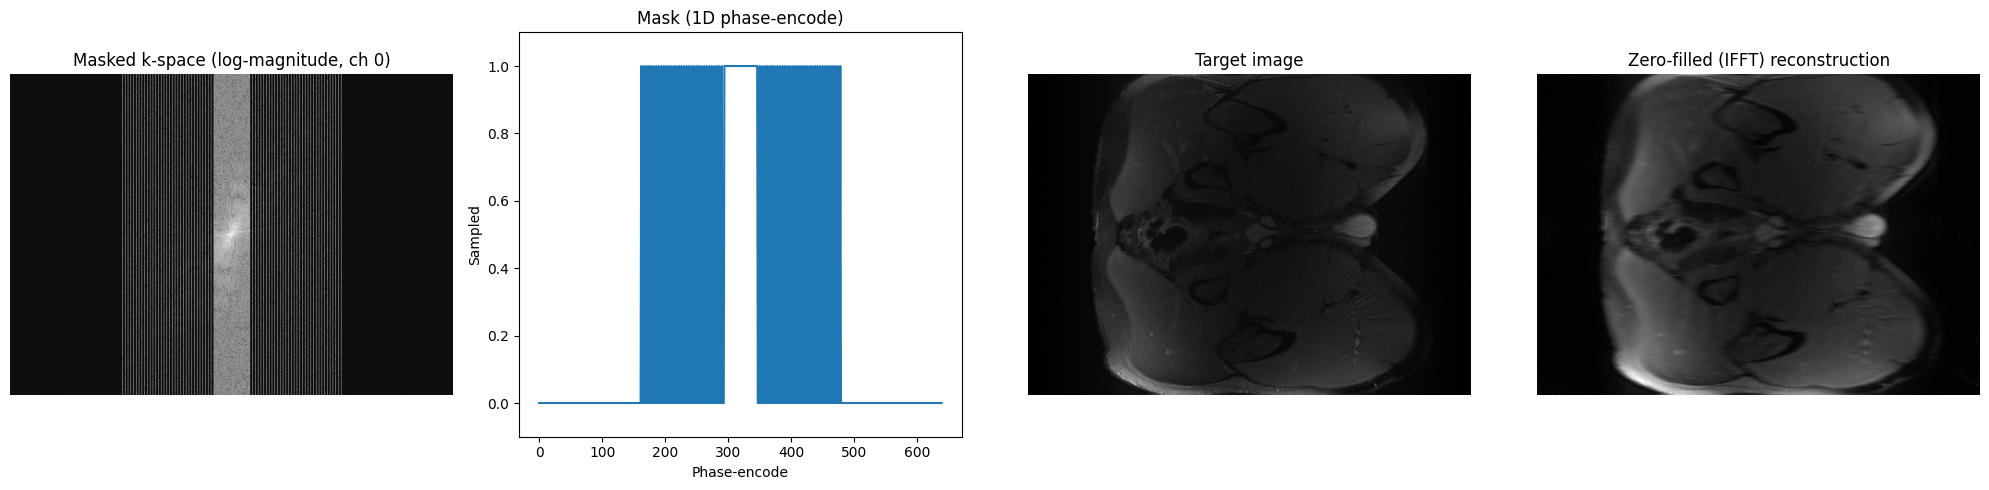

In [42]:
from fastmri.data import SliceDataset
from fastmri.data.subsample import create_mask_for_mask_type
from fastmri.data import transforms as T
data_path = '../../../../../data/datasets/msk_mri_h5/test2'
#data_path = './fast_mri_samples'
mask_func = create_mask_for_mask_type("equispaced", [0.08], [4])
data_transform = T.VarNetDataTransform(mask_func=mask_func)
#data_transform = VarNetDataTransformAutoMask(mask_func=mask_func)
dataset = SliceDataset(root=data_path, transform=data_transform, challenge="multicoil")

# Plot masked k-space, mask, target image, and zero-filled (IFFT) reconstruction for the first sample
import matplotlib.pyplot as plt
import torch
import numpy as np

#sample = dataset_new_test[58]
#sample= dataset_old_test[504]
sample = dataset[0]

masked_kspace = sample.masked_kspace # torch tensor, shape: (num_coils, height, width, 2)
mask = sample.mask.numpy()
target = sample.target.numpy()

# For visualization, take the first channel of masked_kspace and show log-magnitude
masked_kspace_np = masked_kspace.numpy() if hasattr(masked_kspace, 'numpy') else masked_kspace
masked_kspace_mag = np.log(np.abs(masked_kspace_np[0, ..., 0] + 1e-9))
if masked_kspace.shape[-1] == 2:
    masked_kspace_cplx = torch.view_as_complex(masked_kspace)
else:
    masked_kspace_cplx = masked_kspace
img_coils = torch.fft.ifftshift(torch.fft.ifft2(torch.fft.fftshift(masked_kspace_cplx, dim=(-2, -1)), norm="ortho"), dim=(-2, -1))
img_rss = torch.sqrt((img_coils.abs() ** 2).sum(dim=0))
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(masked_kspace_mag, cmap='gray')
axs[0].set_title('Masked k-space (log-magnitude, ch 0)')
axs[0].axis('off')

# Visualize the 1D mask as a line plot
axs[1].plot(np.squeeze(mask))
axs[1].set_title('Mask (1D phase-encode)')
axs[1].set_ylim(-0.1, 1.1)
axs[1].set_xlabel('Phase-encode')
axs[1].set_ylabel('Sampled')

axs[2].imshow(target, cmap='gray')
axs[2].set_title('Target image')
axs[2].axis('off')

axs[3].imshow(img_rss.numpy(), cmap='gray')
axs[3].set_title('Zero-filled (IFFT) reconstruction')
axs[3].axis('off')

plt.tight_layout()
plt.show()